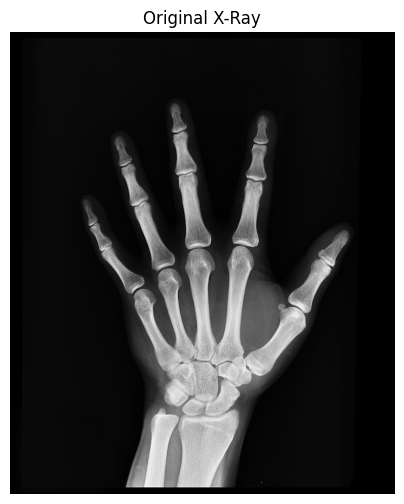

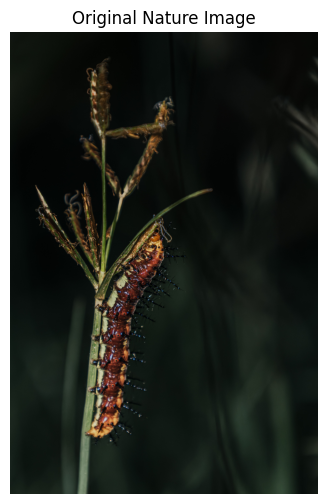

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to display images properly
def show_image(title, image, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off') # Hide axes for cleaner look
    plt.show()

# Load the images using the filenames you provided
# cv2 reads images in BGR format by default, so we convert them to RGB for normal viewing
img_xray = cv2.imread('pexels-pixabay-207496.jpg')
img_xray_rgb = cv2.cvtColor(img_xray, cv2.COLOR_BGR2RGB)

img_nature = cv2.imread('pexels-ceylonframes-37821765.jpg')
img_nature_rgb = cv2.cvtColor(img_nature, cv2.COLOR_BGR2RGB)

show_image("Original X-Ray", img_xray_rgb)
show_image("Original Nature Image", img_nature_rgb)

1. Grayscale conversion

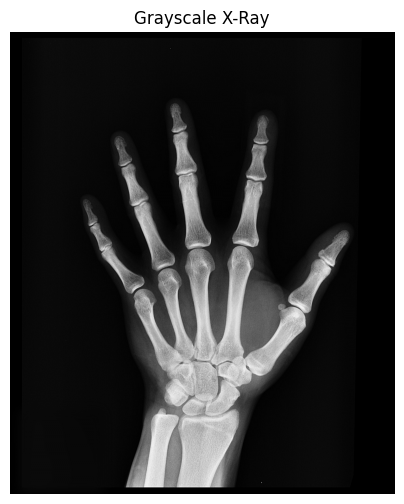

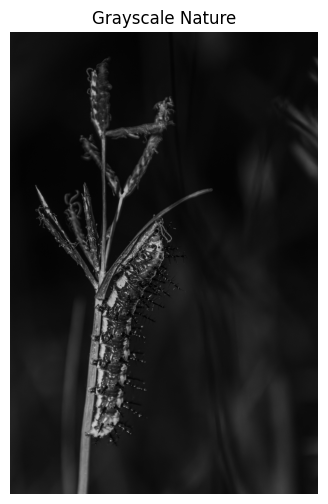

In [3]:
# Convert both images to grayscale
gray_xray = cv2.cvtColor(img_xray, cv2.COLOR_BGR2GRAY)
gray_nature = cv2.cvtColor(img_nature, cv2.COLOR_BGR2GRAY)

show_image("Grayscale X-Ray", gray_xray, cmap='gray')
show_image("Grayscale Nature", gray_nature, cmap='gray')

2. Histogram Visualisation

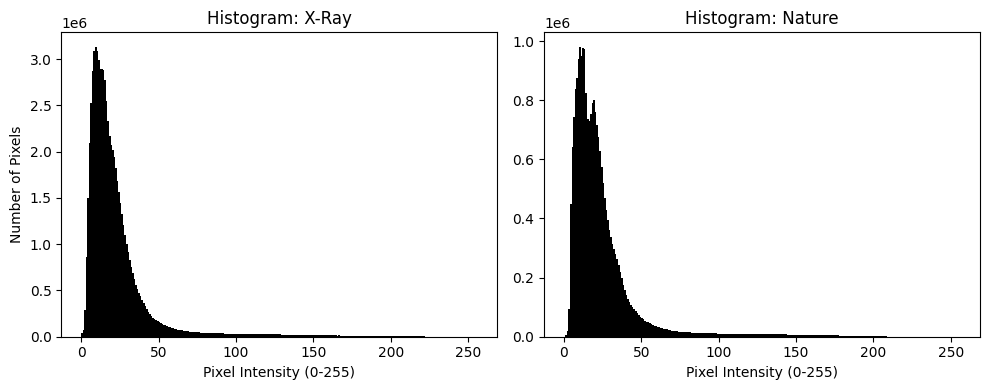

In [11]:
# Flatten the 2D array of pixels into a 1D array to calculate the histogram
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img_nature_rgb.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram: X-Ray')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Number of Pixels')

plt.subplot(1, 2, 2)
plt.hist(gray_nature.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram: Nature')
plt.xlabel('Pixel Intensity (0-255)')

plt.tight_layout()
plt.show()

3. Image Resizing

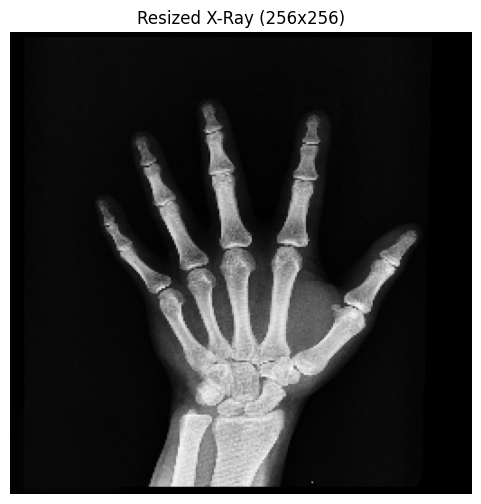

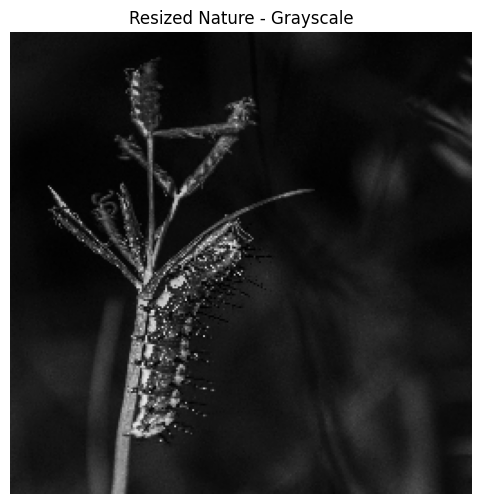

--- Image Shapes ---
X-Ray original: (7175, 5967) -> New: (256, 256)


In [14]:
# new width and height
new_width = 256
new_height = 256

# Resize
resized_xray = cv2.resize(gray_xray, (new_width, new_height))
resized_nature_gray = cv2.resize(gray_nature, (new_width, new_height))

# Display all three results
show_image("Resized X-Ray (256x256)", resized_xray, cmap='gray')
show_image("Resized Nature - Grayscale", resized_nature_gray, cmap='gray')


# Print the shapes to prove they all changed size
print("--- Image Shapes ---")
print(f"X-Ray original: {gray_xray.shape} -> New: {resized_xray.shape}")


4. Edge Detection

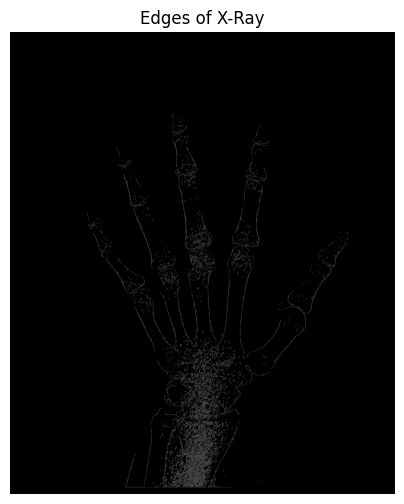

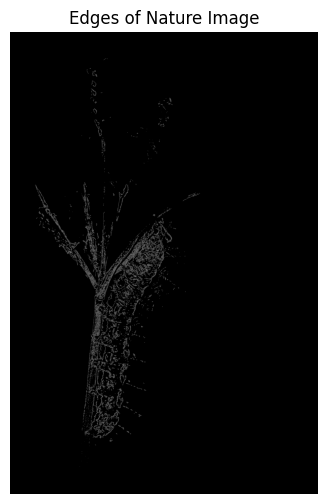

In [15]:
#
# Any gradient above 200 is considered an edge for the nature
edges_xray = cv2.Canny(gray_xray, 30,100)
edges_nature = cv2.Canny(gray_nature, 100, 200)

show_image("Edges of X-Ray", edges_xray, cmap='gray')
show_image("Edges of Nature Image", edges_nature, cmap='gray')

5. Noise Addition and noise removal

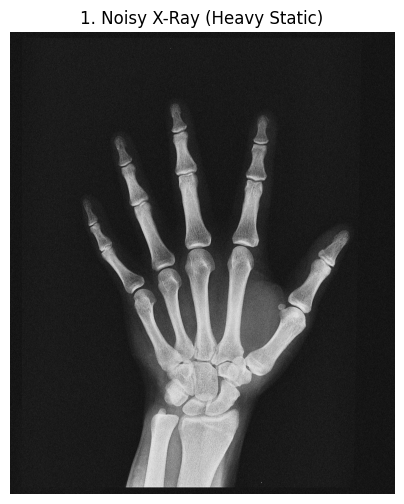

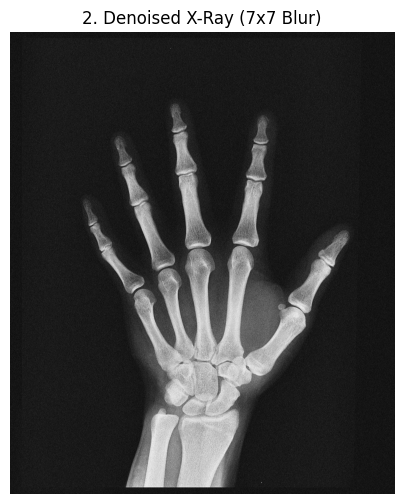

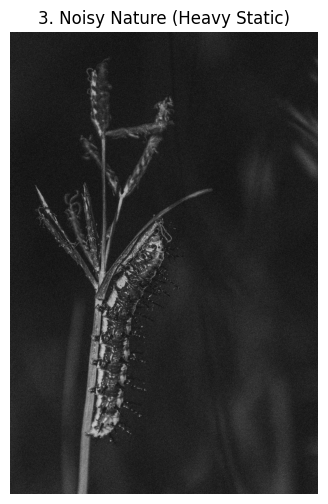

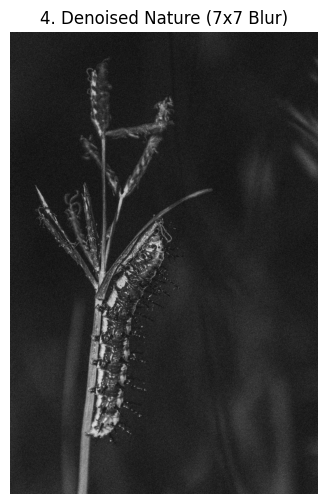

In [17]:
# SET THE NOISE DIAL TO "LOUD"
mean = 0
variance = 3000
sigma = variance ** 0.5

# PART 1: APPLYING TO THE X-RAY

# Generate random noise shaped exactly like X-Ray
row_x, col_x = gray_xray.shape
noise_for_xray = np.random.normal(mean, sigma, (row_x, col_x))

# Add the noise, then force the numbers to stay between 0 and 255
noisy_xray = gray_xray + noise_for_xray
noisy_xray = np.clip(noisy_xray, 0, 255).astype(np.uint8)

# Remove the noise using Gaussian Blur.
# Because the noise is heavier, we increased the "kernel size" from (5,5) to (7,7)
denoised_xray = cv2.GaussianBlur(noisy_xray, (7, 7), 0)


# PART 2: APPLYING TO THE NATURE IMAGE

# Generate random noise shaped exactly like our Nature image
row_n, col_n = gray_nature.shape
noise_for_nature = np.random.normal(mean, sigma, (row_n, col_n))

# Add the noise, then force the numbers to stay between 0 and 255
noisy_nature = gray_nature + noise_for_nature
noisy_nature = np.clip(noisy_nature, 0, 255).astype(np.uint8)

# Remove the noise
denoised_nature = cv2.GaussianBlur(noisy_nature, (7, 7), 0)

# DISPLAY ALL 4 RESULTS

show_image("1. Noisy X-Ray (Heavy Static)", noisy_xray, cmap='gray')
show_image("2. Denoised X-Ray (7x7 Blur)", denoised_xray, cmap='gray')

show_image("3. Noisy Nature (Heavy Static)", noisy_nature, cmap='gray')
show_image("4. Denoised Nature (7x7 Blur)", denoised_nature, cmap='gray')